In [180]:
# ============================================================
# IMPORTACIONES
# ============================================================
import json
import pickle
import warnings

import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import torch
import torch.nn as nn
import yfinance as yf
from matplotlib.gridspec import GridSpec
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILIDAD
# ============================================================
# Fijar semillas globales garantiza que los resultados sean reproducibles
# entre ejecuciones, incluyendo el orden aleatorio de los mini-batches.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[DISPOSITIVO] Usando: {DEVICE}")


[DISPOSITIVO] Usando: cpu


In [181]:
# ============================================================
# SECCIÓN 0: CONFIGURACIÓN
# ============================================================
# Fuente única de verdad para todos los hiperparámetros del pipeline.
# Modificar aquí evita inconsistencias entre secciones.
CONFIG = {
    # --- Datos ---
    "ticker":     "SPY",
    "start_date": "1995-01-01",

    # --- Divisiones cronológicas (estrictamente sin solapamiento) ---
    "train_end": "2016-01-01",
    "val_end":   "2022-01-01",

    # --- Configuración de secuencias y características ---
    "lookback":         11,    # L: longitud de la ventana histórica de la LSTM
    "forecast_horizon": 5,     # H: horizonte de predicción en días hábiles
    "window_trailing":  5,    # ventana del estandarizador rolling (~3 meses)
    "smoothing_window": 5,    # ventana para suavizado opcional de targets (no requerido)
    # Características seleccionadas para la LSTM
    "features": [
        "rv_daily",       # componente diario HAR-RV:  r_t^2
        "rv_weekly",      # componente semanal HAR-RV: promedio 5 días
        "rv_monthly",     # componente mensual HAR-RV: promedio 22 días
        "log_return",     # retorno log (proxy de momentum de precio)
        "parkinson_vol",  # estimador alta-baja Parkinson (1980) [corrección C2]
        "rsi_14",         # RSI 14 días (proxy de microestructura)
        "rel_volume",     # volumen relativo (proxy de liquidez)
        "intraday_range", # rango intradía normalizado (proxy vol intradía)
    ],

    # --- Arquitectura LSTM ---
    "hidden":  16,   # dimensión del estado oculto (mantener bajo para SNR bajo)
    "dropout": 0.16,  # tasa de dropout en capas recurrente y densa

    # --- Entrenamiento ---
    "batch_size":   128 ,
    "lr":           1e-4,   # tasa de aprendizaje muy baja para evitar oscilaciones en SNR bajo
    "weight_decay": 1e-3,   # regularización L2
    "min_epochs":   50,     # número mínimo de épocas antes de considerar detención temprana
    "max_epochs":   1000,
    "patience":     15,     # épocas sin mejora antes de detención temprana
    "grad_clip":    1.0,    # norma máxima del gradiente

    # --- Backtest ---
    "cost_bps": 5,          # costo de transacción unilateral en puntos base

    # --- Rutas de salida ---
    "model_path":         "lstm_vol_model.pt",
    "scaler_path":        "scaler.pkl",
    "metrics_path":       "metrics.csv",
    "report_path":        "report.md",
    "config_path":        "model_config.json",
    "plot_path":          "lstm_vol_report.png",
    "target_scaler_path": "target_scaler.pkl",
}

# Persistir la configuración en disco para reproducibilidad del experimento
with open(CONFIG["config_path"], "w") as f:
    json.dump(
        {k: v for k, v in CONFIG.items() if isinstance(v, (str, int, float, bool, list))},
        f, indent=2,
    )
print("[CONFIG] Guardada en:", CONFIG["config_path"])


[CONFIG] Guardada en: model_config.json


In [182]:
# ============================================================
# SECCIÓN 1: ADQUISICIÓN DE DATOS
# ============================================================

def download_data(ticker: str, start: str) -> pd.DataFrame:
    """
    Descarga datos OHLCV ajustados desde Yahoo Finance.

    auto_adjust=True aplica correcciones por dividendos y splits automáticamente.
    Retorna un DataFrame limpio con columnas: Open, High, Low, Close, Volume.

    Validaciones:
    - NaN: forward-fill (máximo 1 observación consecutiva esperada)
    - Precios no positivos: error crítico de integridad
    - Movimientos > 15%: flaggeados pero retenidos (e.g., COVID-19, GFC)
    """
    print(f"\n[DATOS] Descargando {ticker} desde {start}...")
    raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)

    # Aplanar MultiIndex de columnas si lo genera la versión reciente de yfinance
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    raw = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
    raw.index = pd.to_datetime(raw.index)
    raw = raw.sort_index()

    # Validar: valores faltantes
    n_nan = raw.isnull().sum().sum()
    if n_nan > 0:
        print(f"  ADVERTENCIA: {n_nan} valores NaN detectados. Aplicando forward-fill.")
        raw = raw.ffill().dropna()

    # Validar: precios no positivos (error de integridad en los datos fuente)
    if (raw[["Open", "High", "Low", "Close"]] <= 0).any().any():
        raise ValueError("Precio no positivo detectado — error de integridad en los datos.")

    # Marcar movimientos extremos sin eliminarlos (crisis legítimas)
    log_ret   = np.log(raw["Close"] / raw["Close"].shift(1)).dropna()
    n_extreme = (np.abs(log_ret) > 0.15).sum()
    if n_extreme > 0:
        print(f"  INFO: {n_extreme} movimientos diarios > 15% detectados (retenidos).")

    print(f"  Forma: {raw.shape} | {raw.index[0].date()} → {raw.index[-1].date()}")
    return raw


raw = download_data(CONFIG["ticker"], CONFIG["start_date"])



[DATOS] Descargando SPY desde 1995-01-01...
  Forma: (7903, 5) | 1995-01-03 → 2026-05-28


## Sección 2: Ingeniería de Características

Todas las características son estrictamente causales: en el tiempo $t$ se usa únicamente información disponible hasta $t$ (inclusive).

### Definiciones matemáticas

**Retorno logarítmico**
$$r_t = \log\frac{C_t}{C_{t-1}}$$

**Componentes HAR-RV (Corsi, 2009)**
$$\mathrm{RV}_t^{(d)} = r_t^2, \qquad
  \mathrm{RV}_t^{(w)} = \frac{1}{5}\sum_{i=0}^{4} r_{t-i}^2, \qquad
  \mathrm{RV}_t^{(m)} = \frac{1}{22}\sum_{i=0}^{21} r_{t-i}^2$$

**Estimador Parkinson (1980) [corrección C2]** — opera sobre el cuadrado del log-rango:
$$\sigma_P = \sqrt{\frac{1}{4\ln 2}\,\mathrm{rolling\_mean}\!\left[\left(\ln\frac{H_t}{L_t}\right)^2,\, n\right]}$$

**Estimador Garman-Klass (1980)**
$$\sigma_{GK}^2 = \tfrac{1}{2}\left(\ln\frac{H_t}{L_t}\right)^2 - (2\ln 2-1)\left(\ln\frac{C_t}{O_t}\right)^2$$

**RSI (Wilder, normalizado a $[0,1]$)**
$$\mathrm{rsi\_14} = \frac{1}{100}\left(100 - \frac{100}{1+RS}\right), \qquad RS = \frac{\mathrm{EMA}(\text{ganancias})}{\mathrm{EMA}(\text{pérdidas})}$$

**Volumen relativo e intradía**
$$\mathrm{rel\_volume}_t = \frac{V_t}{\mathrm{MA}_{20}(V)}, \qquad
  \mathrm{intraday\_range}_t = \frac{H_t - L_t}{C_{t-1}}$$

**Target: log-volatilidad realizada forward a $H$ días**
$$y_t = \log\sqrt{\frac{252}{H}\sum_{i=1}^{H} r_{t+i}^2}$$

La construcción usa `.shift(-H)` para alinear el target con el tiempo $t$: no hay look-ahead en las características.


In [183]:
# ============================================================
# SECCIÓN 2: INGENIERÍA DE CARACTERÍSTICAS
# ============================================================

def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye características predictoras estrictamente causales.

    En el tiempo t, solo se accede a información disponible hasta t.
    Ver celda Markdown anterior para las definiciones matemáticas.
    """
    feat = pd.DataFrame(index=df.index)

    # --- Retorno logarítmico ---
    feat["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

    # --- Componentes HAR-RV (Corsi, 2009) ---
    # La ventana rolling incluye el día corriente, consistente con la
    # especificación original de Corsi donde RV_t^(w) promedia sobre
    # [t-4, ..., t] (5 días, incluyendo el presente).
    rv_sq = feat["log_return"] ** 2
    feat["rv_daily"]   = rv_sq                     # varianza del día corriente
    feat["rv_weekly"]  = rv_sq.rolling(5).mean()   # promedio 5 días (incluyendo t)
    feat["rv_monthly"] = rv_sq.rolling(22).mean()  # promedio 22 días (incluyendo t)

    # --- Volatilidad rolling cierre-a-cierre (anualizada, 20 días) ---
    feat["vol_20"] = feat["log_return"].rolling(20).std() * np.sqrt(252)

    # --- Estimador Parkinson (1980) [corrección C2 aplicada] ---
    # Se cuadra el log-rango ANTES de promediar (la especificación correcta).
    # Error frecuente: promediar log(H/L) antes de dividir por 4*ln(2).
    hl_log_sq = np.log(df["High"] / df["Low"]) ** 2
    feat["parkinson_vol"] = np.sqrt(
        hl_log_sq.rolling(20).mean() / (4.0 * np.log(2))
    )

    # --- Estimador Garman-Klass (1980) ---
    hl2 = 0.5 * np.log(df["High"] / df["Low"]) ** 2
    co2 = (2.0 * np.log(2) - 1.0) * np.log(df["Close"] / df["Open"]) ** 2
    # clip(lower=0): evita raíces imaginarias por ruido numérico en hl2 < co2
    feat["gk_vol"] = np.sqrt((hl2 - co2).clip(lower=0).rolling(20).mean())

    # --- RSI 14 días (suavizado Wilder aproximado por media rolling) ---
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-10)                           # evitar división por cero
    feat["rsi_14"] = (100.0 - 100.0 / (1.0 + rs)) / 100.0 # normalizado a [0, 1]

    # --- Características de volumen ---
    vol_ma20 = df["Volume"].rolling(20).mean()
    feat["rel_volume"]   = df["Volume"] / (vol_ma20 + 1e-10)
    feat["volume_trend"] = df["Volume"].rolling(5).mean() / (vol_ma20 + 1e-10)

    # --- Rango intradía normalizado ---
    # Usar C_{t-1} (shift(1)) como denominador garantiza causalidad estricta.
    feat["intraday_range"] = (df["High"] - df["Low"]) / df["Close"].shift(1)

    # --- Gap de apertura (valor absoluto, normalizado por cierre previo) ---
    feat["gap"] = np.abs(df["Open"] - df["Close"].shift(1)) / df["Close"].shift(1)

    # --- Estadísticos de retorno en ventana corta ---
    feat["skew_5"]     = feat["log_return"].rolling(5).skew()
    feat["mean_ret_5"] = feat["log_return"].rolling(5).mean()

    # --- Transformación logarítmica de columnas estrictamente positivas ---
    # Comprime colas pesadas (distribución log-normal de la volatilidad)
    # y estabiliza la escala antes de la estandarización rolling.
    log_cols = [
        "rv_daily", "rv_weekly", "rv_monthly",
        "vol_20", "parkinson_vol", "gk_vol",
        "rel_volume", "volume_trend", "intraday_range", "gap",
    ]
    for col in log_cols:
        if col in feat.columns:
            feat[col] = np.log(feat[col].clip(lower=1e-12))

    return feat


def compute_target(df: pd.DataFrame, horizon: int = 5) -> pd.Series:
    """
    Log-volatilidad realizada anualizada a H días hacia adelante.

    Definición:
        y_t = log( sqrt( (252/H) * sum_{i=1}^{H} r_{t+i}^2 ) )

    Implementación causal:
        rv_sq.rolling(H).sum() en t  = sum_{i=0}^{H-1} r_{t-i}^2
        .shift(-H) en t              = sum_{i=1}^{H}   r_{t+i}^2  ✓

    Este target es intencionalmente forward-looking: solo se usa como
    variable dependiente. Las características en t no acceden a t+1,...,t+H.
    """
    log_ret    = np.log(df["Close"] / df["Close"].shift(1))
    rv_sq      = log_ret ** 2
    fwd_rv     = rv_sq.rolling(horizon).sum().shift(-horizon)
    target     = np.sqrt((252.0 / horizon) * fwd_rv)
    target_log = np.log(target.clip(lower=1e-12))
    return target_log.rename("target_log_vol")


# --- Construcción del dataset completo ---
feat   = compute_features(raw)
target = compute_target(raw, CONFIG["forecast_horizon"])
# Suavizado rolling de target para reducir ruido extremo en la variable dependiente (opcional)

# dropna elimina:
#   - filas iniciales con NaN por ventanas rolling
#   - las últimas H filas cuyo target requiere datos futuros no disponibles
data = pd.concat([feat, target], axis=1).dropna()
print(f"\n[DATASET] {len(data)} observaciones limpias tras dropna.")
print(f"  Período: {data.index[0].date()} → {data.index[-1].date()}")



[DATASET] 7876 observaciones limpias tras dropna.
  Período: 1995-02-02 → 2026-05-20


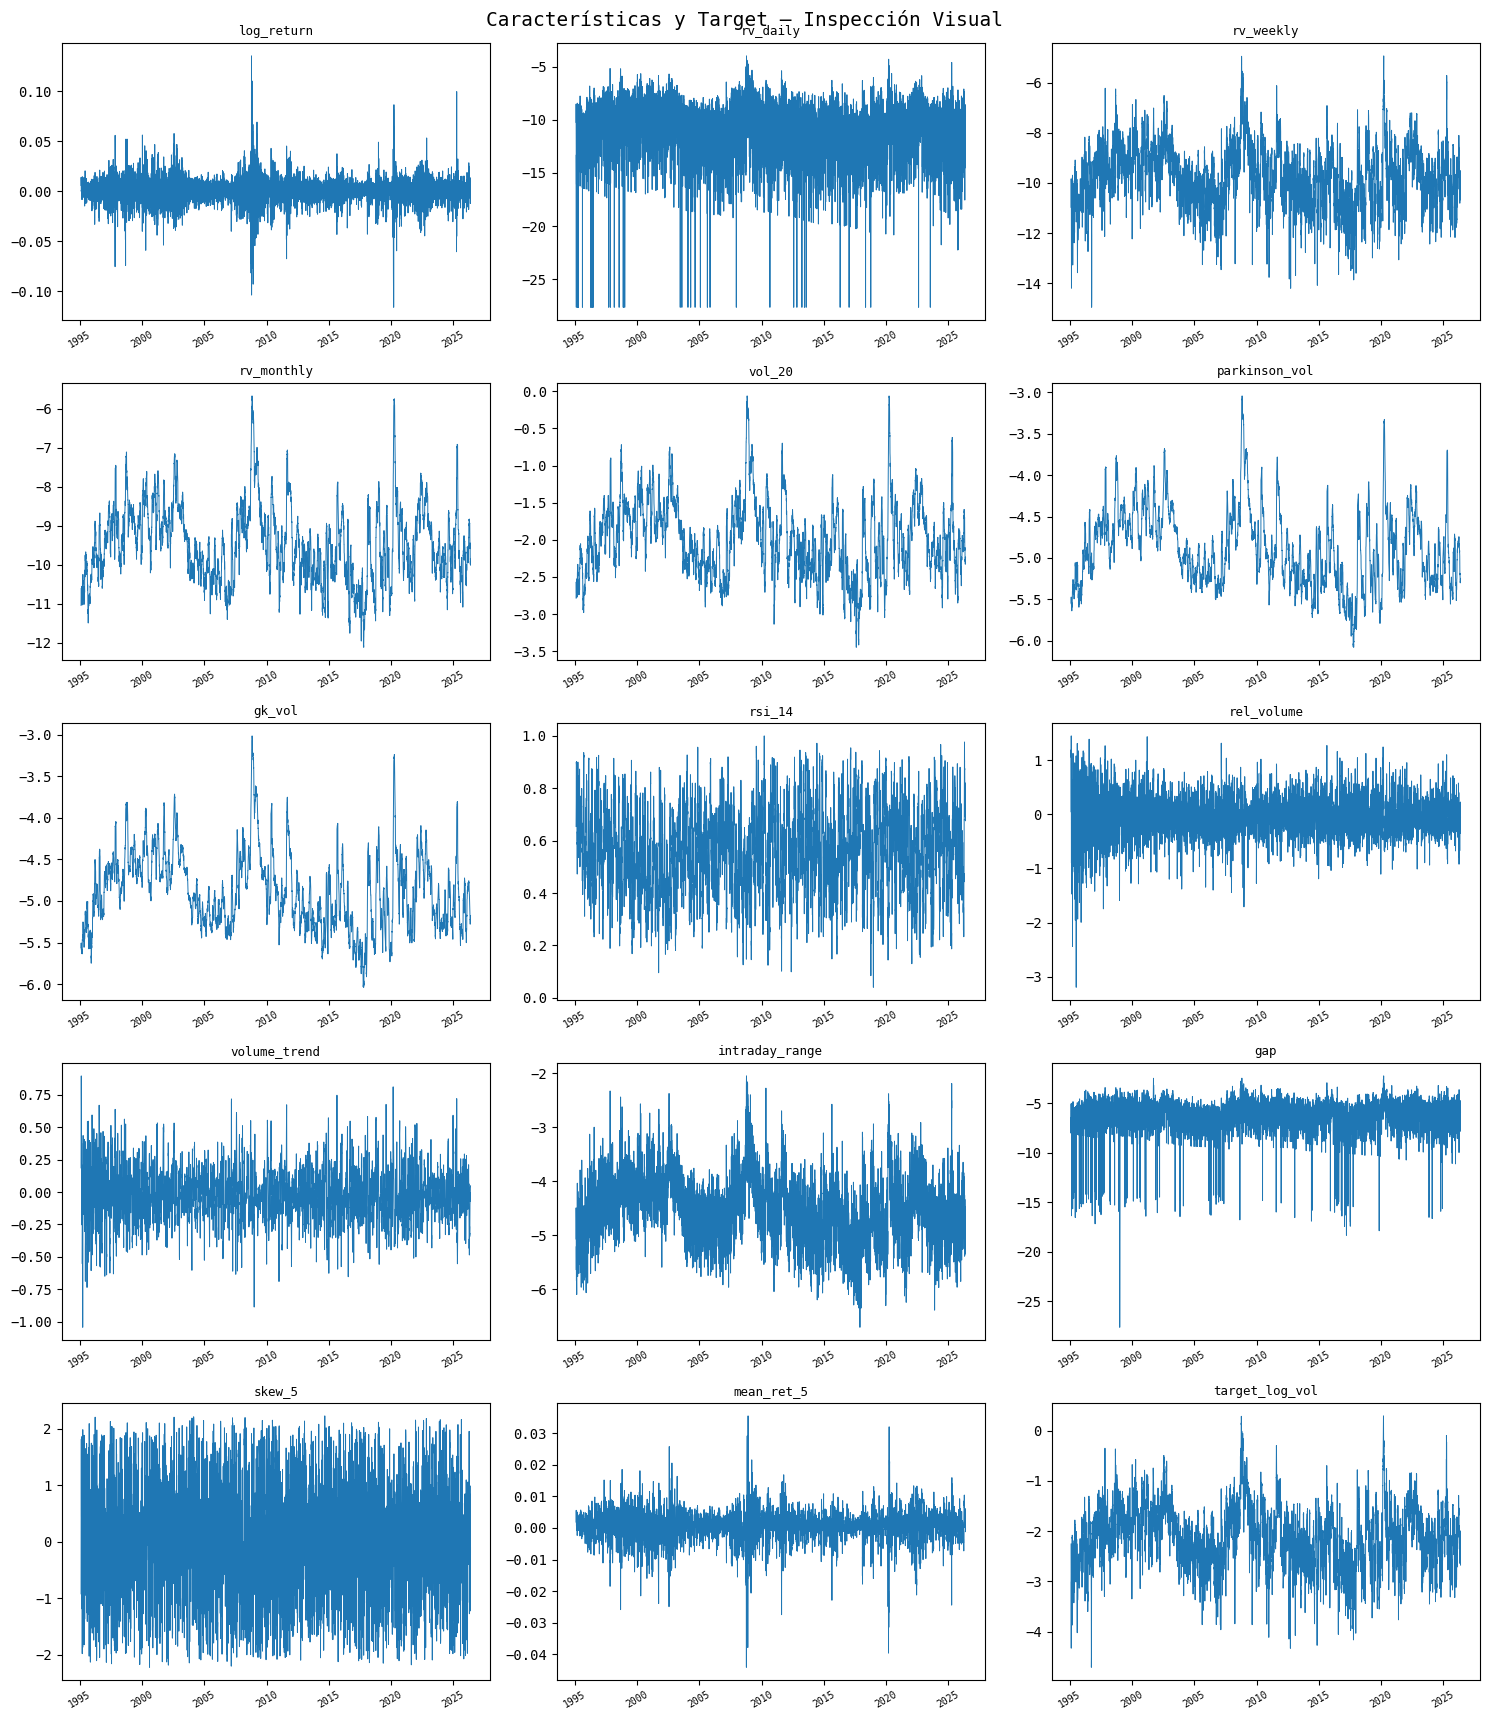

In [184]:
# --- Inspección visual de todas las características y el target ---
# Permite detectar: outliers, cambios de régimen, NaN residuales.
ncols = 3
nrows = int(np.ceil(len(data.columns) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(data.columns):
    axes[i].plot(data.index, data[col], linewidth=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].xaxis.set_major_locator(mdates.YearLocator(5))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)

# Ocultar paneles vacíos si el total de columnas no es múltiplo de ncols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Características y Target — Inspección Visual", fontsize=14)
plt.tight_layout()
plt.savefig("features_raw.png", dpi=100)
plt.show()


In [185]:
# ============================================================
# SECCIÓN 3: DIVISIONES CRONOLÓGICAS Y BASELINE HAR-RV
# ============================================================

# --- Máscaras de división temporal (sin solapamiento) ---
tr_mask = data.index <= CONFIG["train_end"]
vl_mask = (data.index > CONFIG["train_end"]) & (data.index <= CONFIG["val_end"])
te_mask = data.index > CONFIG["val_end"]

fcols = CONFIG["features"]

# --- Arrays de características (float32 para compatibilidad con PyTorch) ---
X_tr = data.loc[tr_mask, fcols].values.astype(np.float32)
X_vl = data.loc[vl_mask, fcols].values.astype(np.float32)
X_te = data.loc[te_mask, fcols].values.astype(np.float32)

# --- Arrays de target en log-vol crudo (sin estandarizar) ---
y_tr = data.loc[tr_mask, "target_log_vol"].values.astype(np.float32)
y_vl = data.loc[vl_mask, "target_log_vol"].values.astype(np.float32)
y_te = data.loc[te_mask, "target_log_vol"].values.astype(np.float32)

# Índice de fechas del período de prueba (para gráficos)
te_dates = data.index[te_mask]

print(f"[DIVISIONES] Train: {len(X_tr)} | Val: {len(X_vl)} | Test: {len(X_te)}")
print(f"  Train: {data.index[tr_mask][0].date()} → {data.index[tr_mask][-1].date()}")
print(f"  Val:   {data.index[vl_mask][0].date()} → {data.index[vl_mask][-1].date()}")
print(f"  Test:  {data.index[te_mask][0].date()} → {data.index[te_mask][-1].date()}")


class HARRVModel:
    """
    Modelo HAR-RV (Corsi, 2009) — benchmark canónico de predicción de volatilidad.

    Especificación:
        y_t = β₀ + β_d·RV_t^(d) + β_w·RV_t^(w) + β_m·RV_t^(m) + ε_t

    donde y_t es el log-vol forward a H días y los componentes RV son los
    valores de las características rv_daily, rv_weekly y rv_monthly en t.

    Estimado por MCO con errores estándar HAC (Newey-West, 10 rezagos) para
    corregir heteroscedasticidad y autocorrelación temporal.

    NOTA DE IMPLEMENTACIÓN: el modelo se entrena y predice en espacio de
    log-vol crudo (no estandarizado), de modo que las predicciones son
    directamente comparables con y_te sin necesidad de inversión.
    Esto contrasta con la LSTM, que trabaja en espacio estandarizado.
    """
    HAR_COLS = ["rv_daily", "rv_weekly", "rv_monthly"]

    def __init__(self):
        self.ols_res_ = None

    def fit(self, X_train: pd.DataFrame, y_train: np.ndarray) -> "HARRVModel":
        """Ajusta el modelo HAR por MCO con covarianza HAC."""
        X_ols = sm.add_constant(X_train[self.HAR_COLS].values)
        self.ols_res_ = sm.OLS(y_train, X_ols).fit(
            cov_type="HAC", cov_kwds={"maxlags": 10}
        )
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Genera predicciones en espacio de log-vol crudo."""
        X_ols = sm.add_constant(X[self.HAR_COLS].values)
        return self.ols_res_.predict(X_ols)

    def summary(self) -> str:
        return str(self.ols_res_.summary())


[DIVISIONES] Train: 5266 | Val: 1511 | Test: 1099
  Train: 1995-02-02 → 2015-12-31
  Val:   2016-01-04 → 2021-12-31
  Test:  2022-01-03 → 2026-05-20


In [186]:
# ============================================================
# SECCIÓN 4: ARQUITECTURA LSTM
# ============================================================

class VolatilityLSTM(nn.Module):
    """
    Red LSTM de capacidad reducida para predicción de volatilidad.

    Motivación del diseño conservador:
        Las series financieras diarias exhiben un ratio señal/ruido (SNR)
        extremadamente bajo. Aumentar la capacidad del modelo más allá de
        lo justificado por los datos conduce a sobreajuste de ruido, no de
        señal. Se prefiere parsimonia explícita sobre complejidad arquitectónica.

    Arquitectura:
        Pre-LayerNorm → LSTM → Dropout → Residual → FC-ELU → Dropout → Escalar

    Diseño técnico:
        - Pre-LN: normalización aplicada ANTES de la LSTM. Estabiliza
          activaciones ante spikes de volatilidad (drawdowns COVID, GFC).
        - Conexión residual: proyección lineal de la entrada al espacio oculto,
          sumada a la salida de la LSTM. Facilita el flujo de gradiente.
        - Cabeza lineal sin restricción de signo: el log-vol estandarizado
          puede ser positivo o negativo.

    Inicialización (Jozefowicz et al., 2015):
        - Pesos recurrentes: ortogonal (previene explosión de escala interna).
        - Forget gate (bias_hh[n//4:n//2]): primeado a 1.0 para retener
          memoria al inicio del entrenamiento.
    """

    def __init__(self, n_features: int, hidden: int = 16, dropout: float = 0.4):
        super().__init__()
        self.hidden = hidden

        # --- Capa recurrente ---
        self.lstm1 = nn.LSTM(n_features, hidden, batch_first=True)

        # --- Pre-LN: normalización de la entrada antes de la LSTM ---
        self.norm1 = nn.LayerNorm(n_features)

        # --- Proyección al espacio oculto para la conexión residual ---
        # Si n_features == hidden, la identidad evita parámetros innecesarios.
        self.project_input = (
            nn.Linear(n_features, hidden) if n_features != hidden else nn.Identity()
        )

        # --- Regularización ---
        self.drop1   = nn.Dropout(p=dropout)       # post-LSTM
        self.drop_fc = nn.Dropout(p=dropout / 2)   # en la cabeza densa (más suave)

        # --- Cabeza de inferencia densa (bottleneck 8 unidades) ---
        self.fc1 = nn.Linear(hidden, 8)
        # ELU: permite activaciones negativas, adecuada para distribuciones de
        # log-vol que incluyen valores negativos (baja volatilidad).
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(8, 1)

        self._init_weights()

    def _init_weights(self) -> None:
        """Inicialización de pesos recurrentes y sesgos."""
        for name, param in self.named_parameters():
            if "weight_ih" in name or "weight_hh" in name:
                # Pesos ortogonales: previenen el crecimiento de escala en
                # secuencias largas (alternativa a Xavier para RNNs).
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                nn.init.constant_(param.data, 0.0)
                if "bias_hh" in name:
                    # Primerear el forget gate a 1.0 fuerza la red a
                    # recordar contexto histórico en las épocas tempranas.
                    n = param.size(0)
                    param.data[n // 4 : n // 2].fill_(1.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagación hacia adelante.

        Args:
            x: [batch, lookback, n_features] — secuencia de características
               estandarizadas con el rolling scaler.

        Returns:
            [batch] — log-vol estandarizado predicho (sin restricción de signo).
        """
        # Proyección de la entrada para la conexión residual
        identity = self.project_input(x)       # [batch, lookback, hidden]

        # Bloque Pre-LN + LSTM + residual
        out_norm = self.norm1(x)               # normalizar antes de la LSTM
        out, _   = self.lstm1(out_norm)
        out      = self.drop1(out)
        out      = out + identity              # conexión residual
      
        # Extraer representación del último paso temporal (día t)
        last = out[:, -1, :]                   # [batch, hidden]

        # Cabeza densa: bottleneck → ELU → dropout → proyección escalar
        dense = self.elu(self.fc1(last))
        dense = self.drop_fc(dense)
        return self.fc2(dense).squeeze(-1)     # [batch]


In [187]:
# ============================================================
# SECCIÓN 5: ESTANDARIZACIÓN ROLLING (SIN FUGA DE DATOS)
# ============================================================

class TrailingStandardScaler(BaseEstimator, TransformerMixin):
    """
    Estandarizador rolling cronológico para series financieras.

    Motivación:
        Un StandardScaler global calcula media y desviación estándar sobre
        el conjunto completo, incluyendo datos de validación y test futuros.
        Esto introduce fuga de información (look-ahead bias) que infla
        artificialmente el rendimiento del modelo.

        Este scaler calcula estadísticos con una ventana trailing de
        `window_size` días, usando únicamente información pasada en cada
        punto temporal.

    Protocolo de uso (sin fuga entre segmentos):
        fit_transform(X_train): historia vacía → rolling puro sobre train.
        transform(X_val):       continúa desde la cola de train (sin reset).
        transform(X_test):      continúa desde la cola de validación.

    Retorna:
        (X_scaled, rolling_mean, rolling_std) — los estadísticos permiten
        invertir la transformación con los valores correctos para cada punto.
    """

    def __init__(self, window_size: int = 21):
        self.window_size = window_size
        self.history_    = None  # contexto histórico para el siguiente segmento
        self.mean_       = None  # estadísticos del último transform()
        self.std_        = None

    @staticmethod
    def _as_2d(X) -> np.ndarray:
        """Convierte cualquier array-like a NumPy 2D."""
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X_arr = X.to_numpy()
        else:
            X_arr = np.asarray(X)
        return X_arr.reshape(-1, 1) if X_arr.ndim == 1 else X_arr

    def fit(self, X, y=None) -> "TrailingStandardScaler":
        """
        Almacena los últimos (window_size - 1) rows de X como historia.
        No escala; solo prepara el contexto para el siguiente transform().
        """
        X_arr = self._as_2d(X)
        tail  = min(len(X_arr), self.window_size - 1)
        self.history_ = X_arr[-tail:] if tail > 0 else np.empty((0, X_arr.shape[1]))
        self.mean_ = None
        self.std_  = None
        return self

    def transform(self, X) -> tuple:
        """
        Escala X con estadísticos rolling y retorna (X_scaled, mean, std).

        Se antepone la historia del segmento previo para que las primeras
        filas de X tengan contexto suficiente en la ventana rolling.
        """
        if self.history_ is None:
            raise ValueError("El scaler no ha sido ajustado. Use fit_transform primero.")

        X_arr    = self._as_2d(X)
        combined = np.vstack([self.history_, X_arr])
        df_comb  = pd.DataFrame(combined)

        roll_mean = df_comb.rolling(self.window_size, min_periods=1).mean().to_numpy(copy=True)
        roll_std  = df_comb.rolling(self.window_size, min_periods=1).std().to_numpy(copy=True)

        # Reemplazar std nulo o NaN para evitar división por cero
        roll_std[roll_std == 0]      = 1e-8
        roll_std[np.isnan(roll_std)] = 1.0

        scaled_comb = (combined - roll_mean) / roll_std

        # Recortar la historia antepuesta: solo retornar los nuevos datos
        idx         = len(self.history_)
        scaled_X    = scaled_comb[idx:]
        scaled_mean = roll_mean[idx:]
        scaled_std  = roll_std[idx:]

        # Actualizar historia para el siguiente segmento
        tail          = min(len(combined), self.window_size - 1)
        self.history_ = combined[-tail:]
        self.mean_    = scaled_mean
        self.std_     = scaled_std

        # Aplanar si la entrada era 1D (columna única del target)
        if scaled_X.shape[1] == 1:
            scaled_X    = scaled_X.ravel()
            scaled_mean = scaled_mean.ravel()
            scaled_std  = scaled_std.ravel()

        return scaled_X, scaled_mean, scaled_std

    def fit_transform(self, X, y=None) -> tuple:
        """Ajusta con historia vacía y escala en un solo paso."""
        X_arr         = self._as_2d(X)
        self.history_ = np.empty((0, X_arr.shape[1]))
        return self.transform(X)

    def inverse_transform(self, X_scaled, mean=None, std=None) -> np.ndarray:
        """
        Invierte la estandarización: X_orig = X_scaled * std + mean.

        Se proveen los estadísticos correspondientes a cada fila de X_scaled
        (los almacenados por el último transform(), o los especificados
        explícitamente para indexación parcial en evaluación).
        """
        mean = mean if mean is not None else self.mean_
        std  = std  if std  is not None else self.std_
        if mean is None or std is None:
            raise ValueError("No hay estadísticos disponibles para inverse_transform.")
        return self._as_2d(X_scaled) * self._as_2d(std) + self._as_2d(mean)


# ── Aplicar estandarización rolling a características ──────────────────
window_trailing = CONFIG["window_trailing"]
scaler = TrailingStandardScaler(window_size=window_trailing)

# Train: fit_transform con historia vacía → sin posibilidad de fuga
X_tr_s, X_tr_mean, X_tr_std = scaler.fit_transform(X_tr)

# Val: transform continúa desde la cola del training (historia actualizada)
X_vl_s, X_vl_mean, X_vl_std = scaler.transform(X_vl)

# Test: transform continúa desde la cola de validación
X_te_s, X_te_mean, X_te_std = scaler.transform(X_te)

# ── Estandarización rolling del target (log-vol) ──────────────────────
target_scaler = TrailingStandardScaler(window_size=window_trailing)
y_tr_s, mean_tr, std_tr = target_scaler.fit_transform(y_tr.reshape(-1, 1))
y_vl_s, mean_vl, std_vl = target_scaler.transform(y_vl.reshape(-1, 1))
y_te_s, mean_te, std_te = target_scaler.transform(y_te.reshape(-1, 1))

# Persistir los scalers para inferencia futura (producción o reproducción)
pickle.dump(scaler,        open(CONFIG["scaler_path"],        "wb"))
pickle.dump(target_scaler, open(CONFIG["target_scaler_path"], "wb"))
print("[SCALERS] Estandarización rolling aplicada. Scalers guardados en disco.")


[SCALERS] Estandarización rolling aplicada. Scalers guardados en disco.


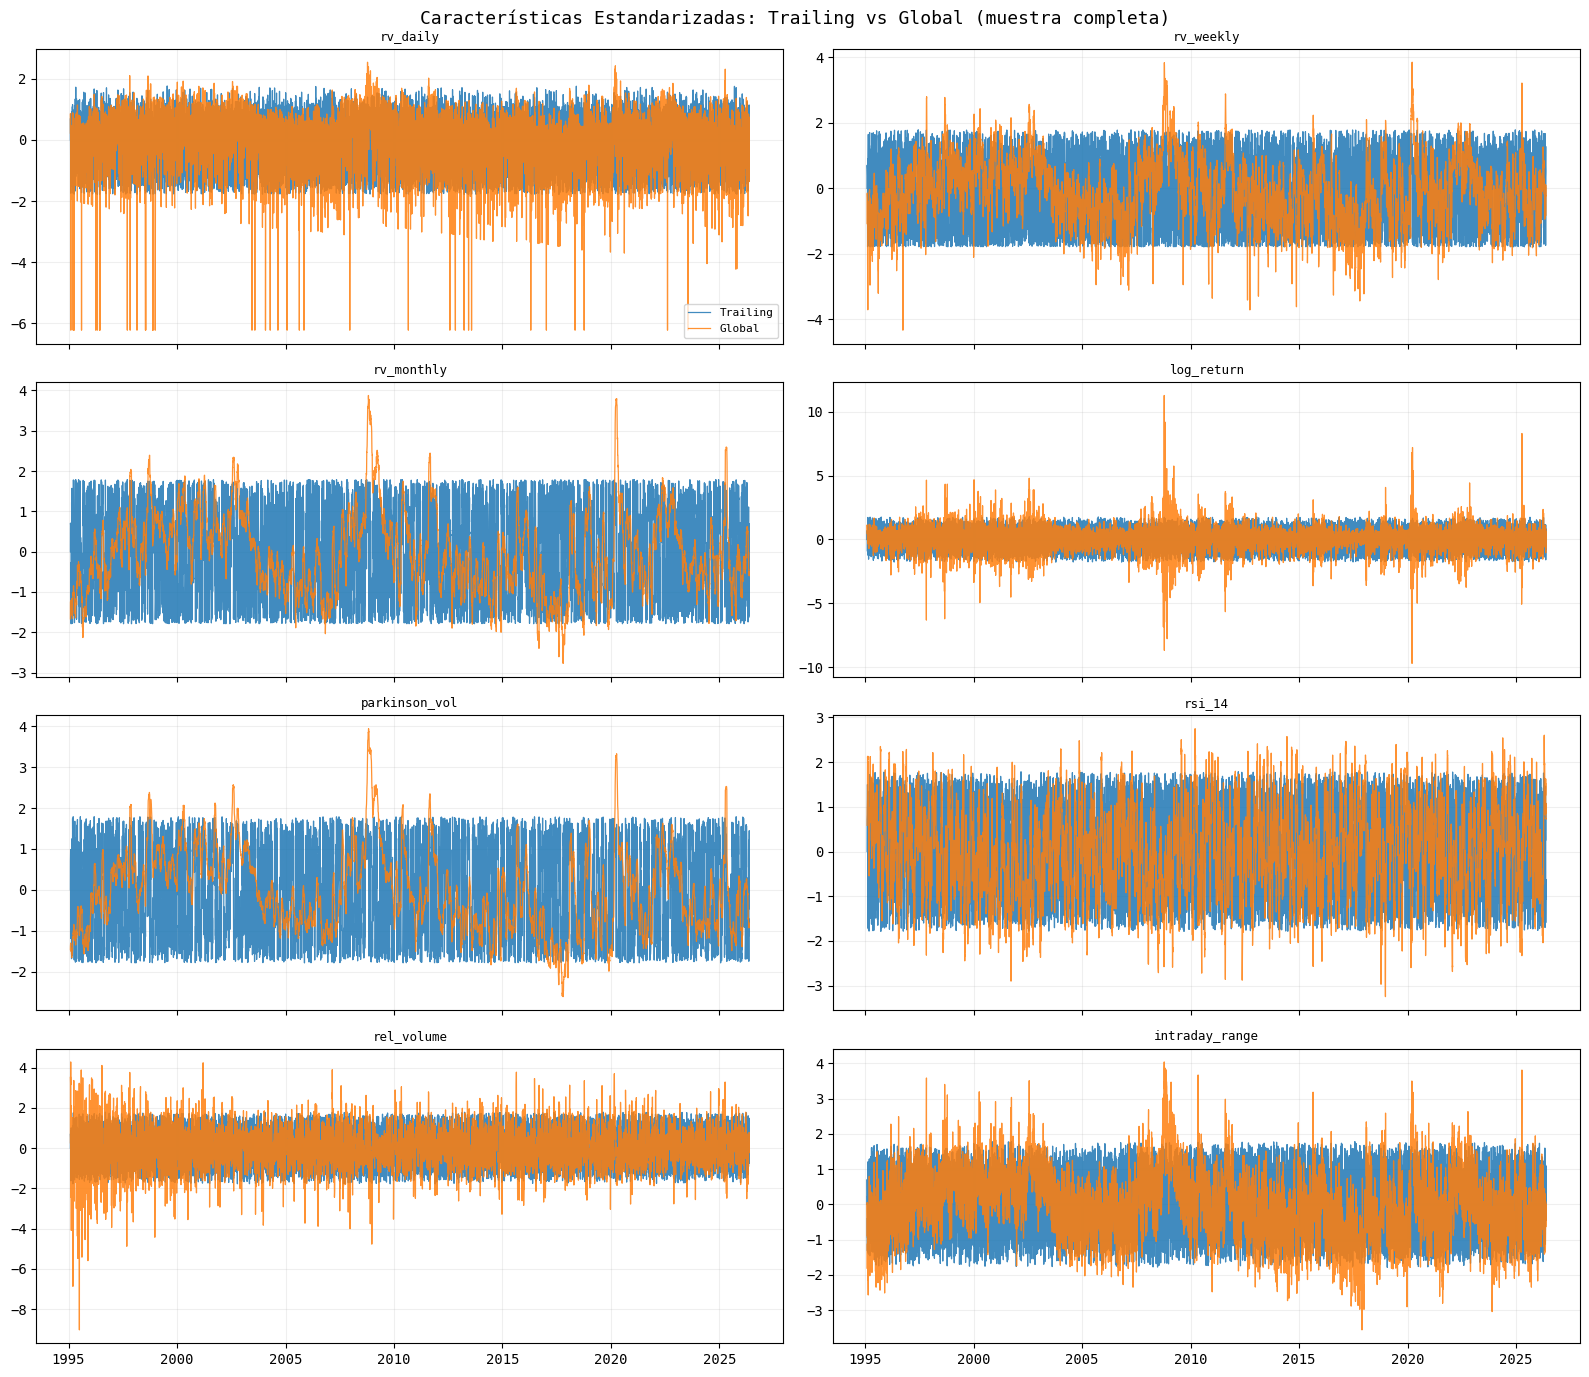

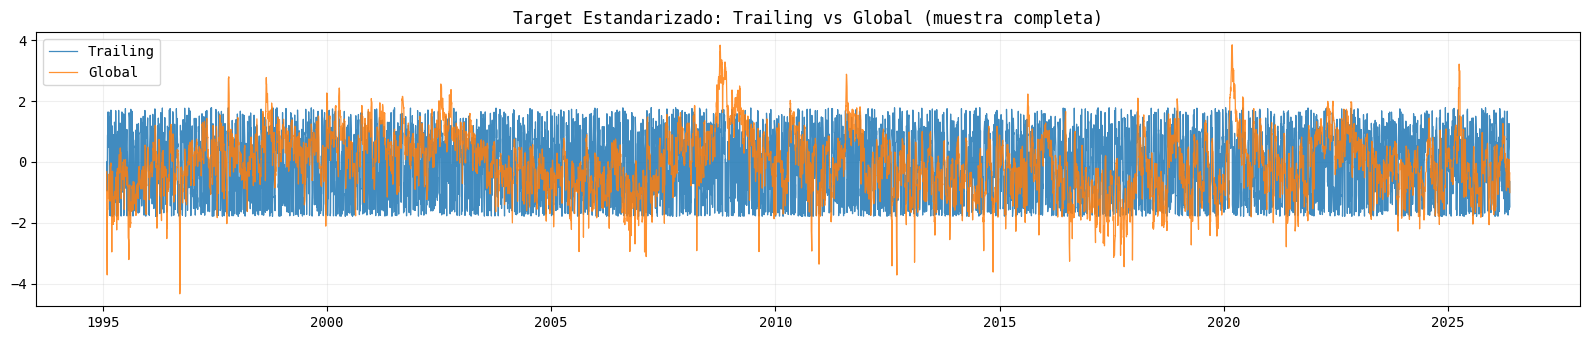

✓ Transformación inversa verificada: log-vol y sigma recuperados dentro de tolerancia.


In [188]:
# --- Diagnóstico: Trailing vs. Global StandardScaler ---
# Visualiza la diferencia entre los dos enfoques de normalización.
# El global introduce look-ahead (usa estadísticos del futuro); el trailing no.
# Esta comparación justifica el uso del rolling scaler en el pipeline.

feature_names = list(fcols)
X_all = data.loc[:, fcols].values.astype(np.float32)

# Trailing sobre el conjunto completo (solo para visualización, historia vacía)
trailing_full = TrailingStandardScaler(window_size=window_trailing)
X_all_trailing, _, _ = trailing_full.fit_transform(X_all)

# Global: introduce look-ahead — solo para referencia visual comparativa
global_scaler = StandardScaler()
X_all_global  = global_scaler.fit_transform(X_all)

ncols = 2
nrows = int(np.ceil(len(feature_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
axes = np.array(axes).ravel()

for i, name in enumerate(feature_names):
    ax = axes[i]
    ax.plot(data.index, X_all_trailing[:, i], label="Trailing", alpha=0.85, linewidth=0.9)
    ax.plot(data.index, X_all_global[:, i],   label="Global",   alpha=0.85, linewidth=0.9)
    ax.set_title(name, fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Características Estandarizadas: Trailing vs Global (muestra completa)", fontsize=13)
plt.tight_layout()
plt.savefig("features_trailing_vs_global.png", dpi=100)
plt.show()

# --- Comparación visual del target estandarizado ---
y_full = np.concatenate([y_tr, y_vl, y_te])
y_s    = np.concatenate([y_tr_s, y_vl_s, y_te_s])
target_global_scaler = StandardScaler()
y_global = target_global_scaler.fit_transform(y_full.reshape(-1, 1)).ravel()

fig, ax = plt.subplots(figsize=(16, 3.5))
ax.plot(data.index, y_s,      label="Trailing", alpha=0.85, linewidth=0.9)
ax.plot(data.index, y_global, label="Global",   alpha=0.85, linewidth=0.9)
ax.set_title("Target Estandarizado: Trailing vs Global (muestra completa)")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.grid(True, alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig("target_trailing_vs_global.png", dpi=100)
plt.show()

# ── Verificación de la transformación inversa ─────────────────────────
# Garantiza que la cadena (estandarización → inversión) no introduce error
# numérico significativo en el período de test.
y_te_recovered = target_scaler.inverse_transform(
    y_te_s, mean=mean_te, std=std_te
).flatten()

assert np.allclose(y_te, y_te_recovered, atol=1e-6), (
    "ERROR: la transformación inversa no recupera el log-vol original de test."
)
assert np.allclose(np.exp(y_te), np.exp(y_te_recovered), atol=1e-6), (
    "ERROR: la exponenciación no recupera sigma correctamente."
)
print("✓ Transformación inversa verificada: log-vol y sigma recuperados dentro de tolerancia.")


In [189]:
# ============================================================
# SECCIÓN 6: CONSTRUCCIÓN DE SECUENCIAS DESLIZANTES
# ============================================================

def make_sequences(X: np.ndarray, y: np.ndarray, lookback: int) -> tuple:
    """
    Construye pares (secuencia, target) con ventana deslizante.

    Para la secuencia i:
        Características : X[i : i + L]    → días i a i+L-1  (incluido)
        Target          : y[i + L]        → día i+L

    Último día observado: i+L-1 (tiempo t).
    Target: volatilidad realizada de t+1 a t+H.
    → Construcción estrictamente causal: no hay look-ahead en las features.

    Args:
        X       : características estandarizadas [T, n_features]
        y       : targets estandarizados [T]
        lookback: longitud L de la ventana histórica

    Returns:
        (Xs, ys): arrays de secuencias y targets (float32)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys,  dtype=np.float32))


LB = CONFIG["lookback"]

# Construir secuencias sobre los targets estandarizados
# (la LSTM aprende a predecir log-vol en espacio normalizado)
Xtr_seq, ytr_seq = make_sequences(X_tr_s, y_tr_s, LB)
Xvl_seq, yvl_seq = make_sequences(X_vl_s, y_vl_s, LB)
Xte_seq, yte_seq = make_sequences(X_te_s, y_te_s, LB)

# # Suavizado opcional de targets estandarizados para reducir ruido extremo (no requerido)
ytr_seq = pd.Series(ytr_seq).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()
yvl_seq = pd.Series(yvl_seq).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()
yte_seq = pd.Series(yte_seq).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()

print(f"[SECUENCIAS] Train: {Xtr_seq.shape} | Val: {Xvl_seq.shape} | Test: {Xte_seq.shape}")
print(f"  Causalidad: secuencia i usa features [i, i+L-1], target en i+L={LB} ✓")


[SECUENCIAS] Train: (5255, 11, 8) | Val: (1500, 11, 8) | Test: (1088, 11, 8)
  Causalidad: secuencia i usa features [i, i+L-1], target en i+L=11 ✓


## Alineación del Baseline HAR-RV con las Secuencias LSTM

Para que la comparación LSTM vs. HAR sea justa, ambos modelos deben usar
el mismo conjunto de información en cada paso de predicción.

La $i$-ésima secuencia LSTM abarca los índices $[i, i+L-1]$. El último día
observado es $i+L-1$ (tiempo $t$). El target es la volatilidad en $[t+1, t+H]$.

El HAR debe predecir usando únicamente la información disponible al final
de la ventana, es decir, el vector de características del día $i+L-1$:

$$\mathbf{x}_{\text{HAR},\, i} = \mathbf{x}_{i+L-1} \in \mathbb{R}^F$$

En Python (indexación base cero): `har_features[i] = data[LB-1 + i]`.

**Target del HAR**: log-vol crudo $y_{i+L}$ (no estandarizado), consistente con
la estimación MCO en escala de log-volatilidad. Las predicciones resultantes
son directamente comparables con `y_te` sin requerir inversión.

$$\hat{y}_{i} = \hat{\alpha} + \hat{\boldsymbol{\beta}}^\top \mathbf{x}_{i+L-1}$$
$$\min_{\alpha,\,\boldsymbol{\beta}} \sum_{i=1}^{N} \left( y_{i+L} - \alpha - \boldsymbol{\beta}^\top \mathbf{x}_{i+L-1} \right)^2$$


In [190]:
import torch
import random
import numpy as np
import pandas as pd
from torch.utils.data import Sampler, DataLoader, TensorDataset

class RegimeBatchSampler(Sampler):
    """
    Custom Sampler que asegura que cada batch contenga una proporción fija
    de secuencias de alta volatilidad (shocks) y secuencias normales (quiet).
    """
    def __init__(
        self, 
        target_series: np.ndarray, 
        batch_size: int, 
        shock_ratio: float = 0.25, 
        sigma_threshold: float = 2.0
    ):
        self.batch_size = batch_size
        self.num_shocks = int(batch_size * shock_ratio)
        self.num_quiet = batch_size - self.num_shocks
        
        # Aplanar la serie objetivo para cálculos estadísticos
        targets = np.array(target_series).flatten()
        y_series = pd.Series(targets)
        
        # Calcular línea base móvil (63 días) para aislar momentos de shock
        rolling_m = y_series.rolling(window=63, min_periods=1).mean()
        rolling_s = y_series.rolling(window=63, min_periods=1).std().bfill()
        
        # Clasificación booleana
        is_shock = targets > (rolling_m + sigma_threshold * rolling_s)
        
        # Crear los Pools de índices
        self.shock_indices = np.where(is_shock)[0].tolist()
        self.quiet_indices = np.where(~is_shock)[0].tolist()
        
        if len(self.shock_indices) == 0:
            print("⚠️ Advertencia: No se detectaron shocks con este umbral. Se usarán datos normales.")
            self.shock_indices = self.quiet_indices
            
        # El número de batches se rige por el tamaño total del dataset
        self.num_batches = len(targets) // batch_size

    def __iter__(self):
        # 1. Barajar ambos pools al inicio de cada época (Epoch)
        random.shuffle(self.shock_indices)
        random.shuffle(self.quiet_indices)
        
        shock_pool = self.shock_indices.copy()
        quiet_pool = self.quiet_indices.copy()
        
        for _ in range(self.num_batches):
            batch = []
            
            # 2. Extraer datos para el Shock Pool (oversampling si se agota)
            for _ in range(self.num_shocks):
                if not shock_pool:
                    shock_pool = self.shock_indices.copy()
                    random.shuffle(shock_pool)
                batch.append(shock_pool.pop())
                
            # 3. Extraer datos para el Quiet Pool
            for _ in range(self.num_quiet):
                if not quiet_pool:
                    quiet_pool = self.quiet_indices.copy()
                    random.shuffle(quiet_pool)
                batch.append(quiet_pool.pop())
                
            # 4. Barajar el interior del batch (para no pasar siempre los shocks primero)
            random.shuffle(batch)
            
            # Entregar la lista de índices a PyTorch
            yield batch

    def __len__(self):
        return self.num_batches

In [191]:
# ── DataLoaders para la LSTM ─────────────────────────────────────────

# 1. Crear el TensorDataset igual que antes
train_ds = TensorDataset(torch.from_numpy(Xtr_seq), torch.from_numpy(ytr_seq))

# 2. Instanciar nuestro nuevo Sampleador Estratificado
# CONFIG["batch_size"] suele ser 32 o 64. 
# shock_ratio=0.25 significa que el 25% de CADA batch serán muestras de crisis.
sigma_threshold=1 #es un umbral común para definir shocks como eventos que superan 2 desviaciones estándar por encima de la media móvil.


regime_sampler = RegimeBatchSampler(
    target_series=ytr_seq, 
    batch_size=CONFIG["batch_size"], 
    shock_ratio=0.5,        
    sigma_threshold=sigma_threshold     
)

# 3. Inicializar el DataLoader (notar que usamos `batch_sampler`)
# train_loader = DataLoader(
#     train_ds, 
#     batch_sampler=regime_sampler
# )
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                            shuffle=True, drop_last=True)

# Convertir a serie y calcular el porcentaje de eventos en 2 líneas
y_s = pd.Series(ytr_seq.flatten())
porcentaje = (y_s > (y_s.rolling(63, min_periods=1).mean() + sigma_threshold * y_s.rolling(63, min_periods=1).std().bfill())).mean() * 100

print(f"Porcentaje de eventos en el dataset: {porcentaje:.2f}%")

# Validación y test como tensores estáticos (no requieren DataLoader)
X_vl_t = torch.from_numpy(Xvl_seq)
y_vl_t = torch.from_numpy(yvl_seq)
X_te_t = torch.from_numpy(Xte_seq)

# ── Ajuste del Baseline HAR-RV ────────────────────────────────────────
print("\n[HAR-RV] Ajustando baseline...")

# ── Alineación de características HAR con las secuencias LSTM ──────
# Secuencia i → último día de features en índice i+LB-1 dentro del segmento.
# Se usan features RAW (log-transformadas, no estandarizadas) para MCO.
har_cols_tr = data.loc[tr_mask, fcols].values
har_X_tr    = pd.DataFrame(
    har_cols_tr[LB - 1 : LB - 1 + len(ytr_seq)], columns=fcols
)

har_cols_vl = data.loc[vl_mask, fcols].values
har_X_vl    = pd.DataFrame(
    har_cols_vl[LB - 1 : LB - 1 + len(yvl_seq)], columns=fcols
)

har_cols_te = data.loc[te_mask, fcols].values
har_X_te    = pd.DataFrame(
    har_cols_te[LB - 1 : LB - 1 + len(yte_seq)], columns=fcols
)

# ── Target raw (log-vol sin estandarizar) alineado con las secuencias ──
# ytr_seq[i] = y_tr_s[i+LB] → log-vol crudo correspondiente: y_tr[i+LB]
# El HAR se entrena en el mismo espacio que y_te para comparación directa.
y_tr_raw_aligned = y_tr[LB : LB + len(ytr_seq)]

har = HARRVModel()
har.fit(har_X_tr, y_tr_raw_aligned)  # target crudo, no estandarizado
print(har.summary())

# Predicciones del HAR en espacio de log-vol crudo (sin inversión posterior)
y_pred_har_te = har.predict(har_X_te)[: len(yte_seq)]


Porcentaje de eventos en el dataset: 19.98%

[HAR-RV] Ajustando baseline...
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     296.3
Date:                Thu, 28 May 2026   Prob (F-statistic):          1.11e-177
Time:                        17:15:13   Log-Likelihood:                -3277.7
No. Observations:                5255   AIC:                             6563.
Df Residuals:                    5251   BIC:                             6590.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [192]:
# ============================================================
# SECCIÓN 7: PIPELINE DE ENTRENAMIENTO
# ============================================================

class ExponentialAsymmetricLoss(nn.Module):
    """
    Pérdida LINEX (LINear-EXponential) asimétrica para predicción de volatilidad.

    Formulación:
        L(e) = exp(b·e) - b·e - 1,    e = y - ŷ  (error positivo = subestimación)

    Motivación:
        En riesgo financiero, subestimar la volatilidad es más costoso que
        sobreestimarla (un VaR demasiado bajo puede generar pérdidas catastróficas).
        La LINEX penaliza subestimaciones exponencialmente y sobreestimaciones
        linealmente, modelando esta asimetría de costos.

    El entrenamiento opera en espacio estandarizado (log-vol rolling-scaled),
    donde la pérdida LINEX es bien condicionada.

    Args:
        b: coeficiente de asimetría. b > 0 penaliza subestimaciones.
           Valores típicos: [0.5, 2.0]. b = 1.5 es un punto de partida razonable.
    """

    def __init__(self, b: float = 1.5):
        super().__init__()
        self.b = b

    def forward(self, y_hat: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # Error positivo → subestimación (y > ŷ) → penalización exponencial
        e    = y - y_hat
        loss = (torch.exp(self.b * e) - (self.b * e) - 1.0)
        return torch.mean(loss)  # Escalar para evitar valores extremos en las primeras épocas


def train_lstm(
    model: VolatilityLSTM,
    train_loader: DataLoader,
    X_val_t: torch.Tensor,
    y_val_t: torch.Tensor,
    config: dict,
) -> dict:
    """
    Bucle de entrenamiento con:
        - Optimizador Adam + weight decay (regularización L2)
        - Scheduler ReduceLROnPlateau (reduce lr si val_loss estanca)
        - Gradient clipping (norm máxima = config["grad_clip"])
        - Early stopping (patience = config["patience"])
        - Checkpointing del mejor modelo (menor val LINEX loss)
        - Monitoreo de clipping: flag si > 5% de los batches son clippeados

    Returns:
        history: dict con listas "train_loss" y "val_loss" por época.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    # Reduce lr a la mitad si val_loss no mejora en 5 épocas (mínimo 1e-6)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5, min_lr=1e-6
    )
    criterion = ExponentialAsymmetricLoss(b=0.1)
    # criterion = nn.MSELoss()  # Usamos MSE para entrenamiento estable; LINEX se evalúa en validación/test

    model.to(DEVICE)
    X_val_t = X_val_t.to(DEVICE)
    y_val_t = y_val_t.to(DEVICE)

    history       = {"train_loss": [], "val_loss": []}
    best_val      = float("inf")
    patience_ctr  = 0
    clip_count    = 0
    total_batches = 0

    for epoch in range(config["max_epochs"]):
        model.train()
        epoch_loss, n_batches = 0.0, 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

            # Descartar mini-batches con NaN (pueden aparecer en los bordes
            # de la ventana rolling del scaler durante la construcción de secuencias)
            if torch.isnan(Xb).any() or torch.isnan(yb).any():
                continue

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(Xb), yb)
            loss.backward()

            # Clipping del gradiente: estabiliza el entrenamiento ante
            # spikes de volatilidad que generan gradientes explosivos
            norm = nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
            if norm > config["grad_clip"]:
                clip_count += 1
            total_batches += 1

            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        # Evaluación en validación (modo eval desactiva dropout)
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        avg_train = epoch_loss / n_batches
        history["train_loss"].append(avg_train)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        # Checkpoint: guardar pesos solo si la val_loss mejora
        if val_loss < best_val:
            best_val     = val_loss
            patience_ctr = 0
            torch.save(model.state_dict(), config["model_path"])
        else:
            patience_ctr += 1

        if (epoch + 1) % 20 == 0:
            print(f"  Época {epoch + 1:3d} | "
                  f"train: {avg_train:.6f} | val: {val_loss:.6f} (LINEX)")

        # Detención temprana: evita sobreajuste cuando el modelo converge
        if patience_ctr >= config["patience"] and epoch >= config["min_epochs"]:
            print(f"  Detención temprana en época {epoch + 1}. "
                  f"Mejor val LINEX loss: {best_val:.6f}")
            break

    # Alerta si el clipping fue frecuente → considerar reducir lr
    clip_pct = 100.0 * clip_count / max(total_batches, 1)
    print(f"  Gradient clipping activado: {clip_pct:.1f}% de los batches.")
    if clip_pct > 5.0:
        print("  *** ALERTA: clipping > 5%. Considerar reducir lr. ***")

    # Restaurar los mejores pesos guardados en checkpoint
    model.load_state_dict(torch.load(config["model_path"], map_location=DEVICE))
    model.eval()
    return history


# ── Instanciar y entrenar la LSTM ─────────────────────────────────────

n_features = Xtr_seq.shape[-1]
model      = VolatilityLSTM(n_features, CONFIG["hidden"], CONFIG["dropout"])
n_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_seq_train = len(ytr_seq)

print(f"\n[LSTM] Parámetros entrenables: {n_params:,}")
print(f"  n_secuencias_train / n_params = {n_seq_train / n_params:.4f}  "
      f"({'OK (>1)' if n_seq_train / n_params > 1 else 'ADVERTENCIA: sobredeterminado'})")

print("\n[LSTM] Entrenando...")
history = train_lstm(model, train_loader, X_vl_t, y_vl_t, CONFIG)



[LSTM] Parámetros entrenables: 1,969
  n_secuencias_train / n_params = 2.6689  (OK (>1))

[LSTM] Entrenando...


  Época  20 | train: 0.001828 | val: 0.002273 (LINEX)
  Época  40 | train: 0.001762 | val: 0.002169 (LINEX)
  Época  60 | train: 0.001725 | val: 0.002137 (LINEX)
  Época  80 | train: 0.001707 | val: 0.002124 (LINEX)
  Época 100 | train: 0.001689 | val: 0.002122 (LINEX)
  Época 120 | train: 0.001694 | val: 0.002122 (LINEX)
  Detención temprana en época 126. Mejor val LINEX loss: 0.002121
  Gradient clipping activado: 0.0% de los batches.


## Sección 8: Métricas de Evaluación

### 1. Métricas de error estándar

$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^N (y_t - \hat{y}_t)^2}, \qquad
  \text{MAE}  = \frac{1}{N}\sum_{t=1}^N |y_t - \hat{y}_t|$$

### 2. Correlación de Spearman

Captura dependencia monotónica (no lineal) entre predicciones y realizaciones.
Más robusta que Pearson ante spikes de volatilidad que distorsionan escalas.

$$\rho_S = 1 - \frac{6\sum d_t^2}{N(N^2-1)}, \qquad d_t = \mathrm{rg}(y_t) - \mathrm{rg}(\hat{y}_t)$$

### 3. Precisión Direccional

Porcentaje de veces que el modelo ubica la predicción y la realización en el mismo lado de la mediana transversal.

$$\text{DA} = \frac{1}{N}\sum_{t=1}^N \mathbf{1}\!\left[\mathrm{sgn}(\hat{y}_t - \mathrm{med}\,\hat{y}) = \mathrm{sgn}(y_t - \mathrm{med}\,y)\right]$$

La significancia se evalúa con un test binomial exacto ($H_0: p = 0.5$).

### 4. Pérdida QLIKE (Patton, 2011)

Robusta a ruido de proxy bajo la clase de pérdidas consistentes con el MSE.

$$\text{QLIKE} = \frac{1}{N}\sum_{t=1}^N \left(\frac{\sigma_t^2}{\hat{\sigma}_t^2} - \ln\frac{\sigma_t^2}{\hat{\sigma}_t^2} - 1\right)$$

Asimetría: sobreestimar $\hat{\sigma}^2 = 2$ cuando $\sigma^2 = 1$ → penalidad 0.193; subestimar $\hat{\sigma}^2 = 0.5$ → penalidad 0.307.

### 5. Regresión Mincer-Zarnowitz

$$y_t = \alpha + \beta\hat{y}_t + e_t$$

$H_0$: $\alpha = 0$ y $\beta = 1$ (predictor insesgado). Estimado con errores HAC (Newey-West).

### 6. Test de Diebold-Mariano (1995)

Compara la precisión predictiva de LSTM vs HAR-RV en el sentido del MSE.

$$d_t = e_{\text{LSTM},t}^2 - e_{\text{HAR},t}^2, \qquad
  \mathrm{DM} = \frac{\bar{d}}{\sqrt{\hat{\omega}^2 / T}} \sim \mathcal{N}(0,1)$$

$\mathrm{DM} < 0$ y $p < 0.05$: la LSTM es significativamente más precisa que HAR-RV.


In [193]:



# ============================================================
# SECCIÓN 8: EVALUACIÓN
# ============================================================

def evaluate_forecasts(y_true: np.ndarray, y_pred: np.ndarray,
                       label: str = "Modelo") -> dict:
    """
    Evaluación comprensiva de pronósticos de volatilidad.

    Todas las métricas operan en espacio de sigma (volatilidad anualizada),
    excepto donde se indique. Los inputs deben estar en la misma escala.

    Métricas:
        R²          : coeficiente de determinación (sentido MCO)
        RMSE        : raíz del error cuadrático medio
        MAE         : error absoluto medio
        Spearman r  : correlación de rango (robusta a no-linealidad)
        Dir. Acc.   : precisión direccional respecto a la mediana
        QLIKE       : pérdida robusta a ruido de proxy (Patton, 2011)
        MZ alpha    : intercepto Mincer-Zarnowitz (H₀: α = 0)
        MZ beta     : pendiente Mincer-Zarnowitz  (H₀: β = 1)
        MZ F p-val  : test conjunto (H₀: α=0 y β=1 simultáneamente)
    """
    # Eliminar NaN e Inf antes de calcular métricas
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isinf(y_true) | np.isinf(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    sp_r, sp_p = stats.spearmanr(y_pred, y_true)

    # Precisión direccional (arriba/abajo de la mediana transversal)
    dir_acc  = np.mean((y_pred > np.median(y_pred)) == (y_true > np.median(y_true)))
    dir_test = stats.binomtest(int(round(dir_acc * len(y_true))), len(y_true), 0.5)
    dir_p    = float(getattr(dir_test, "pvalue", dir_test))

    # QLIKE (Patton, 2011): ratio de varianzas con corrección logarítmica
    eps   = 1e-8
    ratio = y_true ** 2 / (y_pred ** 2 + eps)
    qlike = float(np.mean(ratio - np.log(ratio) - 1.0))

    # Regresión Mincer-Zarnowitz con covarianza HAC (Newey-West, 10 rezagos)
    X_mz   = sm.add_constant(y_pred)
    mz_res = sm.OLS(y_true, X_mz).fit(cov_type="HAC", cov_kwds={"maxlags": 10})
    # Test conjunto: H₀: [α, β] = [0, 1]
    R    = np.eye(2)
    r_v  = np.array([0.0, 1.0])
    mz_f = mz_res.f_test((R, r_v))

    metrics = {
        "model":      label,
        "R2":         float(r2),
        "RMSE":       float(rmse),
        "MAE":        float(mae),
        "Spearman_r": float(sp_r),
        "Spearman_p": float(sp_p),
        "Dir_Acc":    float(dir_acc),
        "Dir_p":      dir_p,
        "QLIKE":      qlike,
        "MZ_alpha":   float(mz_res.params[0]),
        "MZ_beta":    float(mz_res.params[1]),
        "MZ_F_pval":  float(mz_f.pvalue),
        "N":          int(len(y_true)),
    }

    sep = "-" * 46
    print(f"\n{sep}")
    print(f"  {label}")
    print(f"{sep}")
    print(f"  R²:            {r2:+.4f}   (referencia: > 0.08)")
    print(f"  RMSE:          {rmse * 100:.4f}%  (unidades de vol anualizada)")
    print(f"  MAE:           {mae  * 100:.4f}%")
    print(f"  Spearman r:    {sp_r:.4f}   (p = {sp_p:.4f})")
    print(f"  Dir. Accuracy: {dir_acc:.4f}   (p = {dir_p:.4f})")
    print(f"  QLIKE:         {qlike:.6f}")
    print(f"  MZ alpha:      {mz_res.params[0]:.4f}   (H₀: = 0)")
    print(f"  MZ beta:       {mz_res.params[1]:.4f}   (H₀: = 1)")
    print(f"  MZ F p-valor:  {float(mz_f.pvalue):.4f}   (H₀: insesgado)")
    return metrics


def diebold_mariano_test(e1: np.ndarray, e2: np.ndarray, h: int = 5) -> dict:
    """
    Test de Diebold-Mariano (1995) para igualdad de precisión predictiva.

    H₀: los modelos 1 y 2 tienen el mismo MSE esperado.
    Estadístico bajo errores estándar HAC (Newey-West, h-1 rezagos).

    d_t = e1_t² - e2_t²  (diferencial de pérdida)
    DM  = d̄ / sqrt(Var_HAC(d) / T)

    DM < 0 → modelo 1 (LSTM) más preciso que modelo 2 (HAR-RV).ar el DataLoader (notar que usamos `batch_sampler`)
train_loader = DataLoader(
    train_ds, 
    batch_sampler=regime_sampler
)

    Args:
        e1: residuos del modelo 1 (LSTM)
        e2: residuos del modelo 2 (HAR-RV)
        h : horizonte de predicción (determina el número de rezagos HAC)
    """
    d     = e1 ** 2 - e2 ** 2
    d_bar = np.mean(d)
    T     = len(d)

    # Varianza HAC de Newey-West con h-1 rezagos
    gamma0  = np.var(d, ddof=0)
    hac_var = gamma0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k])[0, 1]
        hac_var += 2.0 * (1.0 - k / h) * gamma_k

    se      = np.sqrt(max(hac_var, 1e-12) / T)
    dm_stat = d_bar / se
    dm_pval = 2.0 * (1.0 - stats.norm.cdf(abs(dm_stat)))

    direction = "LSTM más preciso" if dm_stat < 0 else "HAR-RV más preciso"
    sig       = "SIGNIFICATIVO" if dm_pval < 0.05 else "no significativo"

    print(f"\n[TEST DM] LSTM vs HAR-RV: "
          f"stat = {dm_stat:.4f}, p = {dm_pval:.4f}  [{sig}]")
    print(f"  ({direction} bajo criterio MSE)")

    return {"DM_stat": float(dm_stat), "DM_pvalue": float(dm_pval)}


In [194]:
n_features = Xtr_seq.shape[-1]
model = VolatilityLSTM(n_features, CONFIG["hidden"], CONFIG["dropout"])
model.load_state_dict(torch.load(CONFIG["model_path"], map_location=DEVICE))

# ── Predicciones del modelo LSTM sobre el conjunto de test ──────────

model.eval()
with torch.no_grad():
    # y_pred_lstm está en espacio estandarizado (mismo que yte_seq)
    y_pred_lstm = model(X_te_t.to(DEVICE)).cpu().numpy()

# ── Inversión: espacio estandarizado → log-vol crudo ────────────────
# Alinear longitudes por si hay discrepancias menores entre segmentos
n_eval = min(len(yte_seq), len(y_pred_lstm), len(y_pred_har_te))

# Target real: invirtiendo la estandarización rolling del test set.
# yte_seq[i] = y_te_s[i+LB], estandarizado con (mean_te[i+LB], std_te[i+LB]).
# El índice [LB : LB+n_eval] captura exactamente esos estadísticos.
y_true_log = target_scaler.inverse_transform(
    yte_seq[:n_eval],
    mean=mean_te[LB : LB + n_eval],
    std=std_te[LB  : LB + n_eval],
).flatten()

# LSTM: misma inversión aplicada a las predicciones estandarizadas
y_lstm_log = target_scaler.inverse_transform(
    y_pred_lstm[:n_eval],
    mean=mean_te[LB : LB + n_eval],
    std=std_te[LB  : LB + n_eval],
).flatten()

# HAR-RV: las predicciones ya están en log-vol crudo — sin inversión necesaria
# (el modelo fue entrenado sobre targets crudos, no estandarizados)
y_har_log = y_pred_har_te[:n_eval]

# Convertir de log-vol a sigma (volatilidad anualizada, unidades interpretables)
y_true = np.exp(y_true_log)
y_lstm = np.exp(y_lstm_log)
y_har  = np.exp(y_har_log)

# # # Convertir a Moving Average de 5 días para suavizar la serie y enfocarnos en tendencias generales
# y_true = pd.Series(y_true).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()
# y_lstm = pd.Series(y_lstm).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()
# y_har  = pd.Series(y_har).rolling(window=CONFIG["smoothing_window"], min_periods=1).mean().to_numpy()

# ── Evaluación comparativa ────────────────────────────────────────────
print("\n[EVALUACIÓN] Desempeño en el conjunto de test:")
m_lstm = evaluate_forecasts(y_true, y_lstm, label="LSTM")
m_har  = evaluate_forecasts(y_true, y_har,  label="HAR-RV (Baseline)")

# Residuos para el test Diebold-Mariano (en espacio de sigma)
e_lstm = y_true - y_lstm
e_har  = y_true - y_har
dm     = diebold_mariano_test(e_lstm, e_har, h=CONFIG["forecast_horizon"])

# Guardar métricas en CSV
metrics_df = pd.DataFrame([m_lstm, m_har])
metrics_df.to_csv(CONFIG["metrics_path"], index=False)
print(f"\n  Métricas guardadas → {CONFIG['metrics_path']}")

# Check lag correlation in pandas
for lag in [-2, -1, 0, 1, 2]:
    corr = pd.Series(y_true).corr(pd.Series(y_lstm).shift(lag))
    print(f"Correlation at Lag {lag}: {corr:.4f}")


# ── Checklist de validación ───────────────────────────────────────────
print("\n[CHECKLIST DE VALIDACIÓN]")
flags = {
    "R² > 0.08":                m_lstm["R2"]         > 0.08,
    "Dir. Acc. > 0.55":         m_lstm["Dir_Acc"]    > 0.55,
    "Spearman r > 0.15":        m_lstm["Spearman_r"] > 0.15,
    "Spearman p < 0.05":        m_lstm["Spearman_p"] < 0.05,
    "MZ F p > 0.05 (insesgado)": m_lstm["MZ_F_pval"]> 0.05,
}
for check, passed in flags.items():
    icon = "✓" if passed else "✗"
    print(f"  {icon}  {check}")



[EVALUACIÓN] Desempeño en el conjunto de test:

----------------------------------------------
  LSTM
----------------------------------------------
  R²:            +0.9193   (referencia: > 0.08)
  RMSE:          2.6445%  (unidades de vol anualizada)
  MAE:           1.4106%
  Spearman r:    0.9693   (p = 0.0000)
  Dir. Accuracy: 0.9265   (p = 0.0000)
  QLIKE:         0.037689
  MZ alpha:      -0.0140   (H₀: = 0)
  MZ beta:       1.1175   (H₀: = 1)
  MZ F p-valor:  0.0146   (H₀: insesgado)

----------------------------------------------
  HAR-RV (Baseline)
----------------------------------------------
  R²:            +0.2663   (referencia: > 0.08)
  RMSE:          7.9716%  (unidades de vol anualizada)
  MAE:           4.9610%
  Spearman r:    0.5734   (p = 0.0000)
  Dir. Accuracy: 0.7445   (p = 0.0000)
  QLIKE:         0.499734
  MZ alpha:      0.0128   (H₀: = 0)
  MZ beta:       0.9759   (H₀: = 1)
  MZ F p-valor:  0.0616   (H₀: insesgado)

[TEST DM] LSTM vs HAR-RV: stat = -3.3814,

In [195]:
# ============================================================
# SECCIÓN 9: BACKTEST — VOL-TIMING
# ============================================================

def run_vol_timing_backtest(ret: np.ndarray, pred_vol: np.ndarray,
                             cost_bps: float = 5.0) -> dict:
    """
    Estrategia de vol-timing: escalar una posición de momentum por la
    volatilidad predicha inversa (Barroso & Santa-Clara, 2015).

    Señal base: signo del retorno trailing de 63 días (~3 meses).
    Este es un factor de momentum bien documentado e independiente del
    modelo de volatilidad, lo que permite aislar el valor agregado de
    la predicción de volatilidad.

    Posición vol-ajustada:
        pos_vol(t) = clip( señal(t) / (σ̂(t) / σ̄), -1, 1 )

    Costo de transacción (one-way):
        TC(t) = cost_bps × 1e-4 × |Δpos(t)|

    Métricas: Sharpe anualizado, máximo drawdown, ratio de Calmar.
    Factor de anualización: sqrt(252).

    Args:
        ret      : retornos logarítmicos alineados con pred_vol [n_eval]
        pred_vol : volatilidad predicha por la LSTM [n_eval]
        cost_bps : costo unilateral en puntos base
    """
    n       = len(pred_vol)
    ret_arr = ret[:n]

    # Señal de momentum (signo del retorno promedio trailing de 63 días)
    mom_win = min(63, n // 4)
    sig     = np.sign(
        pd.Series(ret_arr).rolling(mom_win).mean().fillna(0).values
    )
    sig[np.isnan(sig)] = 0.0

    # Escalar la señal por la volatilidad predicha normalizada
    sigma_bar = np.mean(pred_vol) + 1e-8
    vol_scale = pred_vol / sigma_bar

    # Posiciones: vol-timed (escalada) vs baseline (sin escalar), ambas clippeadas a [-1, 1]
    pos_vol  = np.clip(sig / (vol_scale + 1e-8), -1.0, 1.0)
    pos_base = np.clip(sig, -1.0, 1.0)

    # Costos de transacción proporcionales al cambio de posición
    cost    = cost_bps * 1e-4
    tc_vol  = cost * np.abs(np.diff(np.r_[0.0, pos_vol]))
    tc_base = cost * np.abs(np.diff(np.r_[0.0, pos_base]))

    ret_vol  = pos_vol  * ret_arr - tc_vol
    ret_base = pos_base * ret_arr - tc_base

    def sharpe(r):
        return np.sqrt(252) * np.mean(r) / (np.std(r) + 1e-10)

    def max_drawdown(r):
        eq   = np.cumprod(1.0 + r)
        peak = np.maximum.accumulate(eq)
        return float(np.min((eq - peak) / (peak + 1e-10)))

    def calmar(r):
        mdd = abs(max_drawdown(r))
        return np.sqrt(252) * np.mean(r) / (mdd + 1e-10)

    return {
        "ret_vol":            ret_vol,
        "ret_base":           ret_base,
        "sharpe_vol":         sharpe(ret_vol),
        "sharpe_base":        sharpe(ret_base),
        "maxdd_vol":          max_drawdown(ret_vol),
        "maxdd_base":         max_drawdown(ret_base),
        "calmar_vol":         calmar(ret_vol),
        "calmar_base":        calmar(ret_base),
        "sharpe_improvement": sharpe(ret_vol) - sharpe(ret_base),
    }


# ── Extraer retornos del test alineados con las secuencias ────────────
# Usar reindex sobre te_dates garantiza que los retornos corresponden
# exactamente al período de test, evitando desajustes de longitud entre
# raw (sin dropna de features) y data (con dropna de features).
te_log_ret = (
    np.log(raw["Close"] / raw["Close"].shift(1))
    .reindex(te_dates)
    .fillna(0.0)
    .values
)
# Las primeras LB fechas del test se consumen en la primera secuencia,
# de modo que las predicciones comienzan en el índice LB del test set.
ret_te_aligned = te_log_ret[LB : LB + n_eval]

# ── Ejecutar backtest ─────────────────────────────────────────────────
print("\n[BACKTEST] Estrategia de vol-timing (período de test)...")
bt = run_vol_timing_backtest(ret_te_aligned, y_lstm, CONFIG["cost_bps"])

print(f"  Sharpe (vol-timed): {bt['sharpe_vol']:.4f}")
print(f"  Sharpe (baseline):  {bt['sharpe_base']:.4f}")
print(f"  Max DD (vol-timed): {bt['maxdd_vol'] * 100:.2f}%")
print(f"  Calmar (vol-timed): {bt['calmar_vol']:.4f}")
print(f"  Mejora Sharpe:      {bt['sharpe_improvement']:+.4f}")

if bt["sharpe_improvement"] > 0.2:
    print("  ✓ Mejora > 0.2 Sharpe: la predicción de vol agrega valor.")
else:
    print("  ✗ Mejora ≤ 0.2: la predicción de vol es marginal para el sizing.")



[BACKTEST] Estrategia de vol-timing (período de test)...
  Sharpe (vol-timed): 1.5064
  Sharpe (baseline):  1.1313
  Max DD (vol-timed): -14.22%
  Calmar (vol-timed): 0.0806
  Mejora Sharpe:      +0.3751
  ✓ Mejora > 0.2 Sharpe: la predicción de vol agrega valor.


In [196]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

def calculate_adaptability(y_true: np.ndarray, y_pred: np.ndarray, horizon: int = 15, threshold: float = 2.0):
    """
    Identifies volatility shocks and calculates the Event-MAE decay curve
    and its exponential half-life for recovery.
    """
    error = np.abs(y_true - y_pred)
    y_s = pd.Series(y_true)
    
    # Define quiet regime using rolling 63-day window
    roll_mean = y_s.rolling(63, min_periods=21).mean()
    roll_std = y_s.rolling(63, min_periods=21).std()
    
    # Flag structural breaks (> 2 standard deviations)
    is_shock = y_s > (roll_mean + threshold * roll_std)
    starts = is_shock & (~is_shock.shift(1).fillna(False))
    shock_indices = np.where(starts)[0]
    
    matrices = []
    for idx in shock_indices:
        if idx + horizon < len(y_true):
            matrices.append(error[idx + 1 : idx + horizon + 1])
            
    if not matrices:
        return np.zeros(horizon), np.nan  # No shocks found
        
    mean_mae = np.mean(matrices, axis=0)
    
    # Fit Exponential Decay: Event-MAE_k = A * e^(-lambda * k) + C
    def decay_func(x, A, lam, C):
        return A * np.exp(-lam * x) + C
        
    x_data = np.arange(1, horizon + 1)
    try:
        p0 = [mean_mae.max() - mean_mae.min(), 0.1, mean_mae.min()]
        popt, _ = curve_fit(
            decay_func, x_data, mean_mae, 
            p0=p0, 
            bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]), 
            maxfev=5000
        )
        lam = popt[1]
        half_life = np.log(2) / lam if lam > 1e-6 else np.nan
    except Exception:
        half_life = np.nan
        
    return mean_mae, half_life


# --- Usage Example ---
profile, half_life = calculate_adaptability(y_true, y_lstm, horizon=50, threshold=2.0)
print(profile)

[0.05437382 0.04493906 0.03671829 0.03176189 0.02621111 0.02192491
 0.0193197  0.01742562 0.01742623 0.0188902  0.02017669 0.01982876
 0.01899837 0.0163795  0.01424804 0.01236702 0.01152618 0.01188859
 0.01238268 0.01146121 0.01193461 0.01420131 0.01817614 0.0202542
 0.0192251  0.01968676 0.02034473 0.02012511 0.02018057 0.01806563
 0.01999938 0.01761875 0.01662738 0.01685226 0.01897503 0.01982379
 0.01901689 0.01807232 0.01862464 0.01863466 0.01853758 0.01839992
 0.01733546 0.01929655 0.0209481  0.01935309 0.01702186 0.01482721
 0.01348554 0.01299712]



[GRÁFICO] Generando figura diagnóstica...


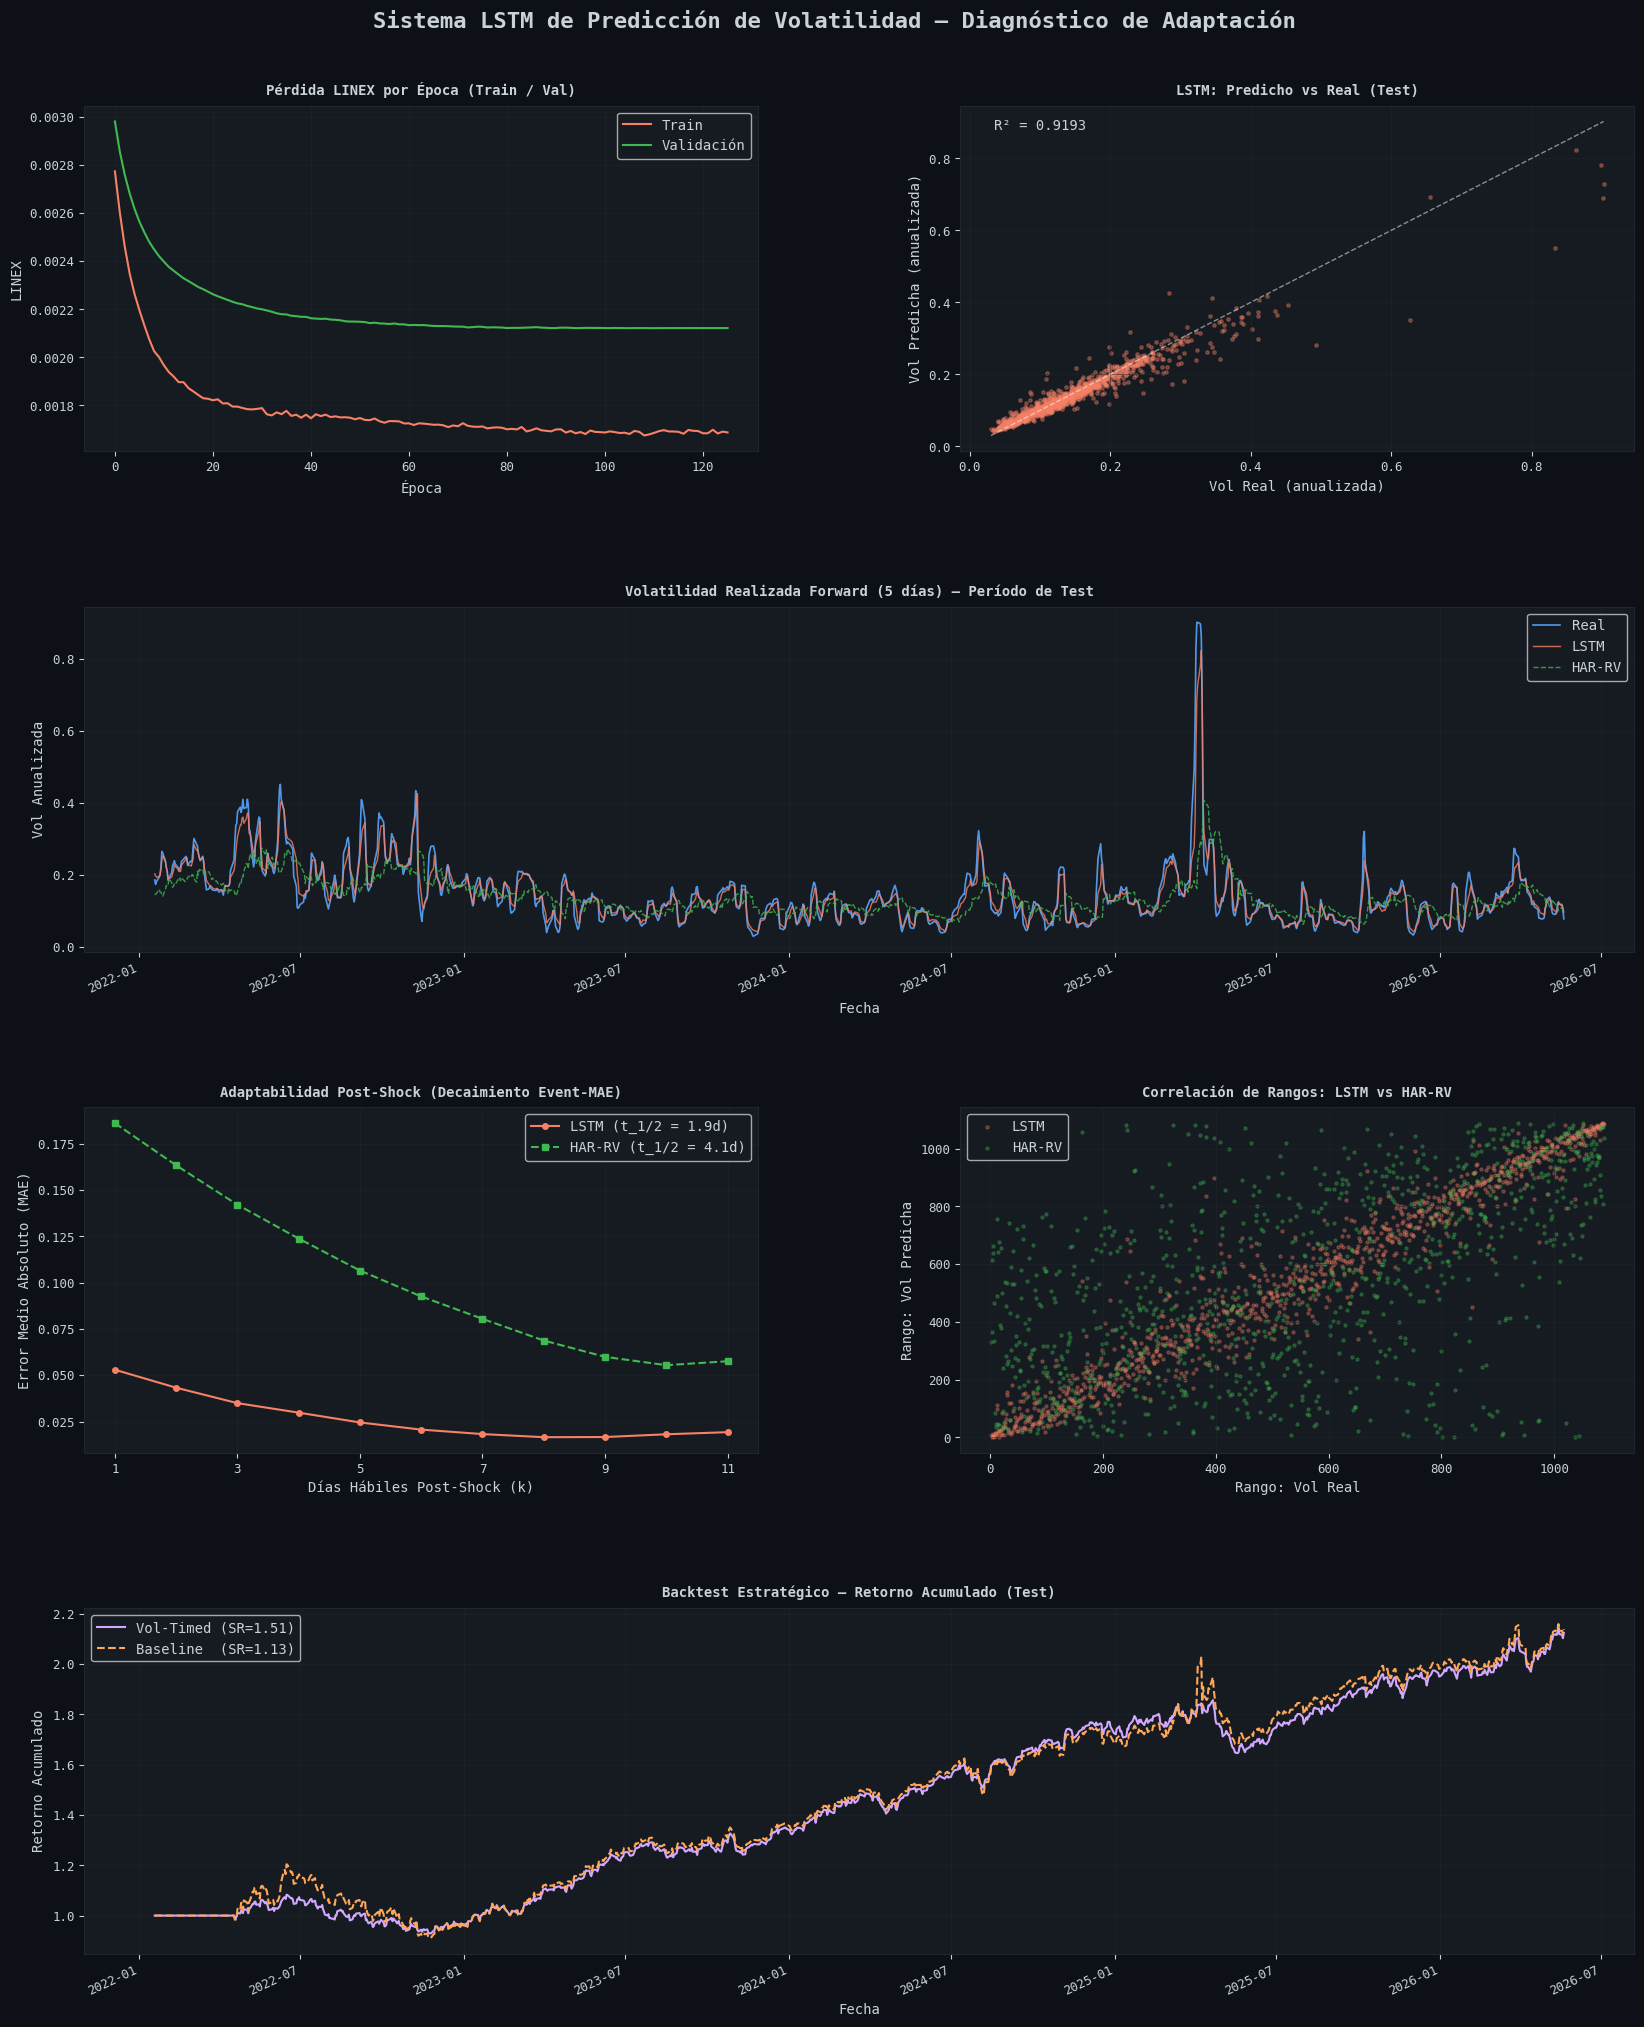

  Figura guardada → lstm_vol_report.png


In [197]:
# ============================================================
# SECCIÓN 10: VISUALIZACIÓN DIAGNÓSTICA
# ============================================================

def generate_plots(
    y_true: np.ndarray,
    y_pred_lstm: np.ndarray,
    y_pred_har: np.ndarray,
    test_dates: pd.DatetimeIndex,
    history: dict,
    bt: dict,
    config: dict,
) -> None:
    """
    Figura diagnóstica optimizada de 6 paneles:

      [0,0] Curvas de pérdida train/val por época
      [0,1] Dispersión: predicho vs real (test set)
      [1,:] Serie temporal: real, LSTM, HAR-RV en el período de test
      [2,0] Curva de Adaptabilidad Event-MAE (con Half-Life)
      [2,1] Dispersión de rangos: LSTM vs HAR-RV
      [3,:] Curvas de equity del backtest (Alineado con fechas)
    """
    matplotlib.rcParams.update({"font.family": "monospace"})

    # Paleta de colores (tema oscuro tipo GitHub)
    BG   = "#0d1117"
    CELL = "#161b22"
    GRID = "#21262d"
    TEXT = "#c9d1d9"
    C = {
        "actual": "#58a6ff", "lstm":   "#f78166",
        "har":    "#3fb950", "volbt":  "#d2a8ff",
        "basebt": "#ffa657", "white":  "#ffffff",
    }

    fig = plt.figure(figsize=(20, 24), facecolor=BG)
    gs  = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

    def ax_style(ax, title=""):
        """Aplica el tema oscuro a un eje."""
        ax.set_facecolor(CELL)
        for side in ax.spines.values():
            side.set_color(GRID)
        ax.tick_params(colors=TEXT, labelsize=9)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.grid(True, color=GRID, linewidth=0.5, alpha=0.7)
        if title:
            ax.set_title(title, color=TEXT, fontweight="bold", pad=8, fontsize=10)

    n  = len(y_true)
    td = test_dates[-n:] if len(test_dates) >= n else pd.RangeIndex(n)

    # --- Panel [0,0]: curvas de pérdida por época ---
    ax = fig.add_subplot(gs[0, 0])
    ax_style(ax, "Pérdida LINEX por Época (Train / Val)")
    ax.plot(history["train_loss"], color=C["lstm"], lw=1.5, label="Train")
    ax.plot(history["val_loss"],   color=C["har"],  lw=1.5, label="Validación")
    ax.set_xlabel("Época")
    ax.set_ylabel("LINEX")
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel [0,1]: dispersión predicho vs real ---
    ax = fig.add_subplot(gs[0, 1])
    ax_style(ax, "LSTM: Predicho vs Real (Test)")
    ax.scatter(y_true, y_pred_lstm, alpha=0.35, s=6, color=C["lstm"])
    lo = min(y_true.min(), y_pred_lstm.min())
    hi = max(y_true.max(), y_pred_lstm.max())
    ax.plot([lo, hi], [lo, hi], "--", color=C["white"], lw=1.0, alpha=0.5)
    ax.text(0.05, 0.93, f"R² = {r2_score(y_true, y_pred_lstm):.4f}",
            transform=ax.transAxes, color=TEXT, fontsize=10)
    ax.set_xlabel("Vol Real (anualizada)")
    ax.set_ylabel("Vol Predicha (anualizada)")

    # --- Panel [1,:]: series temporales ---
    ax = fig.add_subplot(gs[1, :])
    ax_style(ax, "Volatilidad Realizada Forward (5 días) — Período de Test")
    ax.plot(td, y_true,      color=C["actual"], lw=1.2, label="Real",   alpha=0.9)
    ax.plot(td, y_pred_lstm, color=C["lstm"],   lw=1.0, label="LSTM",   alpha=0.8)
    ax.plot(td, y_pred_har,  color=C["har"],    lw=1.0, label="HAR-RV", alpha=0.8, ls="--")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Vol Anualizada")
    ax.legend(facecolor=CELL, labelcolor=TEXT)
    if hasattr(td[0], "strftime"):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

    # --- Panel [2,0]: Curva de Adaptabilidad Event-MAE ---
    ax = fig.add_subplot(gs[2, 0])
    ax_style(ax, "Adaptabilidad Post-Shock (Decaimiento Event-MAE)")
    
    horizon = 11
    mae_lstm, hl_lstm = calculate_adaptability(y_true, y_pred_lstm, horizon=horizon)
    mae_har, hl_har   = calculate_adaptability(y_true, y_pred_har, horizon=horizon)
    
    x_k = np.arange(1, horizon + 1)
    lbl_lstm = f"LSTM (t_1/2 = {hl_lstm:.1f}d)" if not np.isnan(hl_lstm) else "LSTM"
    lbl_har  = f"HAR-RV (t_1/2 = {hl_har:.1f}d)" if not np.isnan(hl_har) else "HAR-RV"
    
    ax.plot(x_k, mae_lstm, color=C["lstm"], marker='o', markersize=4, lw=1.5, label=lbl_lstm)
    ax.plot(x_k, mae_har,  color=C["har"],  marker='s', markersize=4, lw=1.5, ls="--", label=lbl_har)
    
    ax.set_xlabel("Días Hábiles Post-Shock (k)")
    ax.set_ylabel("Error Medio Absoluto (MAE)")
    ax.set_xticks(x_k[::2])
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel [2,1]: correlación de rangos LSTM vs HAR ---
    ax = fig.add_subplot(gs[2, 1])
    ax_style(ax, "Correlación de Rangos: LSTM vs HAR-RV")
    rank_true = stats.rankdata(y_true)
    ax.scatter(rank_true, stats.rankdata(y_pred_lstm),
               color=C["lstm"], alpha=0.3, s=5, label="LSTM")
    ax.scatter(rank_true, stats.rankdata(y_pred_har),
               color=C["har"],  alpha=0.3, s=5, label="HAR-RV")
    ax.set_xlabel("Rango: Vol Real")
    ax.set_ylabel("Rango: Vol Predicha")
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel [3,:]: Curvas de equity del backtest ---
    ax = fig.add_subplot(gs[3, :])
    ax_style(ax, "Backtest Estratégico — Retorno Acumulado (Test)")
    eq_vol  = np.cumprod(1.0 + bt["ret_vol"])
    eq_base = np.cumprod(1.0 + bt["ret_base"])
    
    ax.plot(td, eq_vol,  color=C["volbt"],  lw=1.5,
            label=f"Vol-Timed (SR={bt['sharpe_vol']:.2f})")
    ax.plot(td, eq_base, color=C["basebt"], lw=1.5, ls="--",
            label=f"Baseline  (SR={bt['sharpe_base']:.2f})")
    
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Retorno Acumulado")
    ax.legend(facecolor=CELL, labelcolor=TEXT)
    if hasattr(td[0], "strftime"):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")

    fig.suptitle("Sistema LSTM de Predicción de Volatilidad — Diagnóstico de Adaptación",
                 color=TEXT, fontsize=16, fontweight="bold", y=0.92)

    plt.savefig(config["plot_path"], dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()
    print(f"  Figura guardada → {config['plot_path']}")


# ── Generar figura diagnóstica ────────────────────────────────────────
print("\n[GRÁFICO] Generando figura diagnóstica...")
generate_plots(y_true, y_lstm, y_har, te_dates, history, bt, CONFIG)
